# 군집분석 실습 - 고객segment 분석

## 데이터 로딩

In [1]:
# ! pip install openpyxl

In [24]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
# ! pip install openpyxl

import pandas as pd
data = pd.read_excel('./data/Online Retail.xlsx')

In [3]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 데이터 EDA

### 구조 확인

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
data.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### 전체 중복데이터 확인, 제거

In [6]:
# 1. 중복된 데이터 개수 확인
# duplicated()는 중복된 행 중 '두 번째'부터 True로 표시합니다.
dup_count = data.duplicated().sum()
print(f"🚨 중복된 데이터 총 개수: {dup_count} 건")



🚨 중복된 데이터 총 개수: 5268 건


In [7]:

# -------------------------------------------------------
# 2. [눈으로 확인] 어떤 주문들이 중복인가? (가장 중요!)
# keep=False : 중복된 놈들은 '원본'이든 '복사본'이든 싹 다 가져와라!
# sort_values : 주문번호 순으로 정렬해야 쌍으로 붙어 있어서 비교하기 쉽습니다.
# -------------------------------------------------------
duplicate_rows = data[data.duplicated(keep=False)].sort_values(by=['InvoiceNo', 'StockCode'])

print("\n▼ 중복 데이터 예시 (상위 10개만 출력)")
print(duplicate_rows.head(10)) 

# (선택) 너무 많아서 엑셀로 자세히 보고 싶다면 저장
# duplicate_rows.to_csv("중복데이터_명단.csv", index=False)


▼ 중복 데이터 예시 (상위 10개만 출력)
    InvoiceNo StockCode                       Description  Quantity  \
494    536409     21866       UNION JACK FLAG LUGGAGE TAG         1   
517    536409     21866       UNION JACK FLAG LUGGAGE TAG         1   
485    536409     22111      SCOTTIE DOG HOT WATER BOTTLE         1   
539    536409     22111      SCOTTIE DOG HOT WATER BOTTLE         1   
489    536409     22866     HAND WARMER SCOTTY DOG DESIGN         1   
527    536409     22866     HAND WARMER SCOTTY DOG DESIGN         1   
521    536409     22900   SET 2 TEA TOWELS I LOVE LONDON          1   
537    536409     22900   SET 2 TEA TOWELS I LOVE LONDON          1   
565    536412     21448         12 DAISY PEGS IN WOOD BOX         2   
578    536412     21448         12 DAISY PEGS IN WOOD BOX         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
494 2010-12-01 11:45:00       1.25     17908.0  United Kingdom  
517 2010-12-01 11:45:00       1.25     17908.0  United Kingdom

In [8]:

# -------------------------------------------------------
# 3. [삭제] 중복 제거 (깔끔하게 청소)
# keep='first' (기본값) : 첫 번째 나온 건 살려두고, 뒤에 나온 중복만 지웁니다.
# inplace=True : 원본 df에 바로 적용
# -------------------------------------------------------
df = data.drop_duplicates()

print(f"\n✅ 제거 완료! 남은 데이터 개수: {len(df)} 건")


✅ 제거 완료! 남은 데이터 개수: 536641 건


### 결측치 확인, 제거

In [9]:
def check_missing_unique(df):
    # 1. 기본 정보 (타입, 결측치 개수, 결측치 비율, 고유값 개수)
    result = pd.DataFrame({
        'Data Type': df.dtypes,
        'Missing': df.isnull().sum(),
        'Missing (%)': (df.isnull().sum() / len(df)) * 100,
        'Unique': df.nunique()
    })
    
    # 2. 분포 확인을 위한 '최빈값(Top 1)'과 그 '빈도수(Freq)' 추가
    top_values = []
    top_freqs = []
    
    for col in df.columns:
        try:
            # 가장 많이 나온 값 1개 추출
            top = df[col].value_counts().index[0]
            freq = df[col].value_counts().iloc[0]
        except IndexError: # 데이터가 텅 빈 경우 예외 처리
            top = None
            freq = 0
            
        top_values.append(top)
        top_freqs.append(freq)
        
    result['Top Value'] = top_values
    result['Top Freq'] = top_freqs
    
    # 3. 결측치 많은 순서대로 정렬해서 보여주기
    return result.sort_values(by='Missing (%)', ascending=False)

In [10]:
# 함수 실행
df_summary = check_missing_unique(df)
df_summary

,Data Type,Missing,Missing (%),Unique,Top Value,Top Freq
CustomerID,float64,135037,25.163377,4372,17841.0,7812
Description,object,1454,0.270945,4223,WHITE HANGING HEART T-LIGHT HOLDER,2357
StockCode,object,0,0.000000,4070,85123A,2301
InvoiceNo,object,0,0.000000,25900,573585,1114
Quantity,int64,0,0.000000,722,1,144495
InvoiceDate,datetime64[ns],0,0.000000,23260,2011-10-31 14:41:00,1114
UnitPrice,float64,0,0.000000,1630,1.25,49750
Country,object,0,0.000000,38,United Kingdom,490300


In [11]:
# ! pip install missingno

<Figure size 1000x600 with 0 Axes>

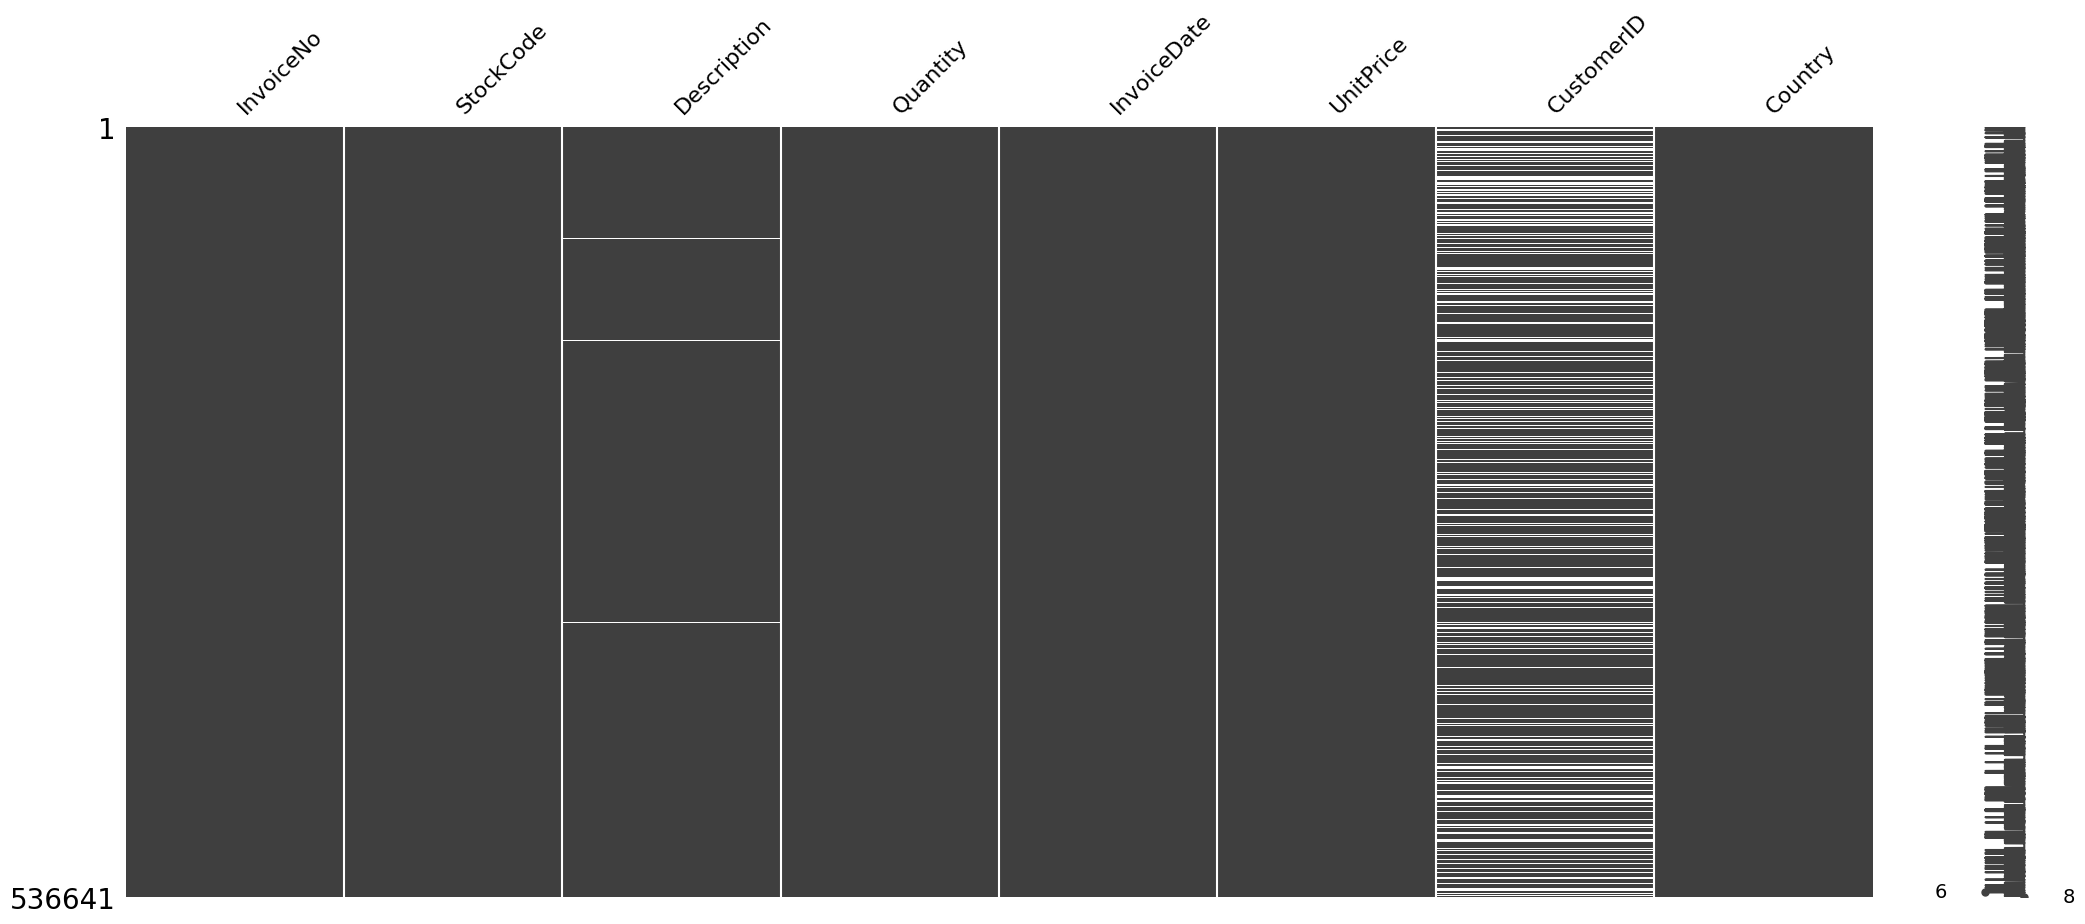

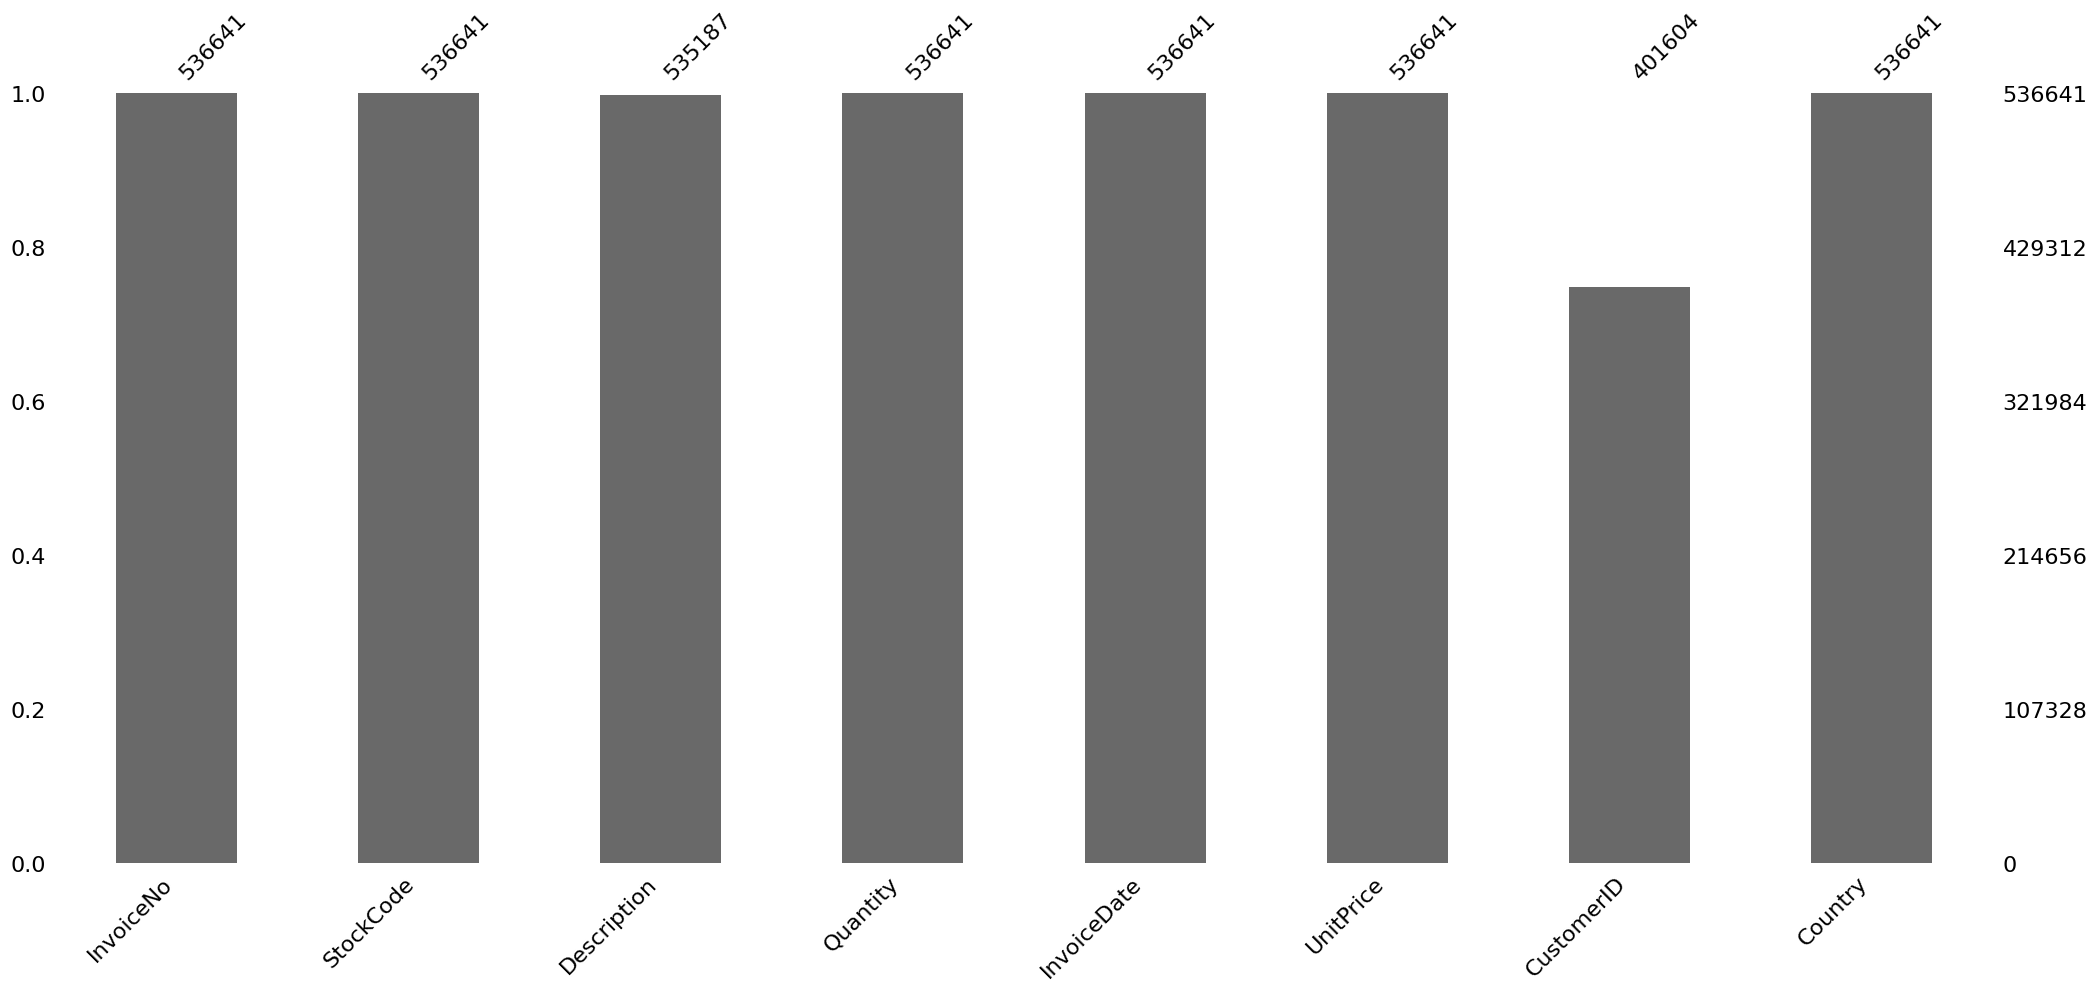

In [12]:
import missingno as msno
import matplotlib.pyplot as plt

# 결측치 패턴 시각화 (흰색 선이 결측치입니다)
plt.figure(figsize=(10, 6))
msno.matrix(df)
plt.show()

# 컬럼별 결측치 개수 막대그래프
msno.bar(df)
plt.show()

In [17]:
df1 = df.dropna(subset=['CustomerID'])
check_missing_unique(df1)

,Data Type,Missing,Missing (%),Unique,Top Value,Top Freq
InvoiceNo,object,0,0.0,22190,576339,542
StockCode,object,0,0.0,3684,85123A,2065
Description,object,0,0.0,3896,WHITE HANGING HEART T-LIGHT HOLDER,2058
Quantity,int64,0,0.0,436,1,69605
InvoiceDate,datetime64[ns],0,0.0,20460,2011-11-14 15:27:00,543
UnitPrice,float64,0,0.0,620,1.25,45813
CustomerID,float64,0,0.0,4372,17841.0,7812
Country,object,0,0.0,37,United Kingdom,356728


In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.6+ MB


In [20]:
df1['TotPrice'] = df1['UnitPrice']*df1['Quantity']

C:\Users\user\AppData\Local\Temp\ipykernel_2408\4142628751.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['TotPrice'] = df1['UnitPrice']*df1['Quantity']


In [21]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    401604 non-null  object        
 1   StockCode    401604 non-null  object        
 2   Description  401604 non-null  object        
 3   Quantity     401604 non-null  int64         
 4   InvoiceDate  401604 non-null  datetime64[ns]
 5   UnitPrice    401604 non-null  float64       
 6   CustomerID   401604 non-null  float64       
 7   Country      401604 non-null  object        
 8   TotPrice     401604 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.6+ MB


In [22]:
df1.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'TotPrice'],
      dtype='object')

C:\Users\user\AppData\Local\Temp\ipykernel_2408\2230595349.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df1, x=col, ax=axes[i], palette='viridis', order=df1[col].value_counts().index)


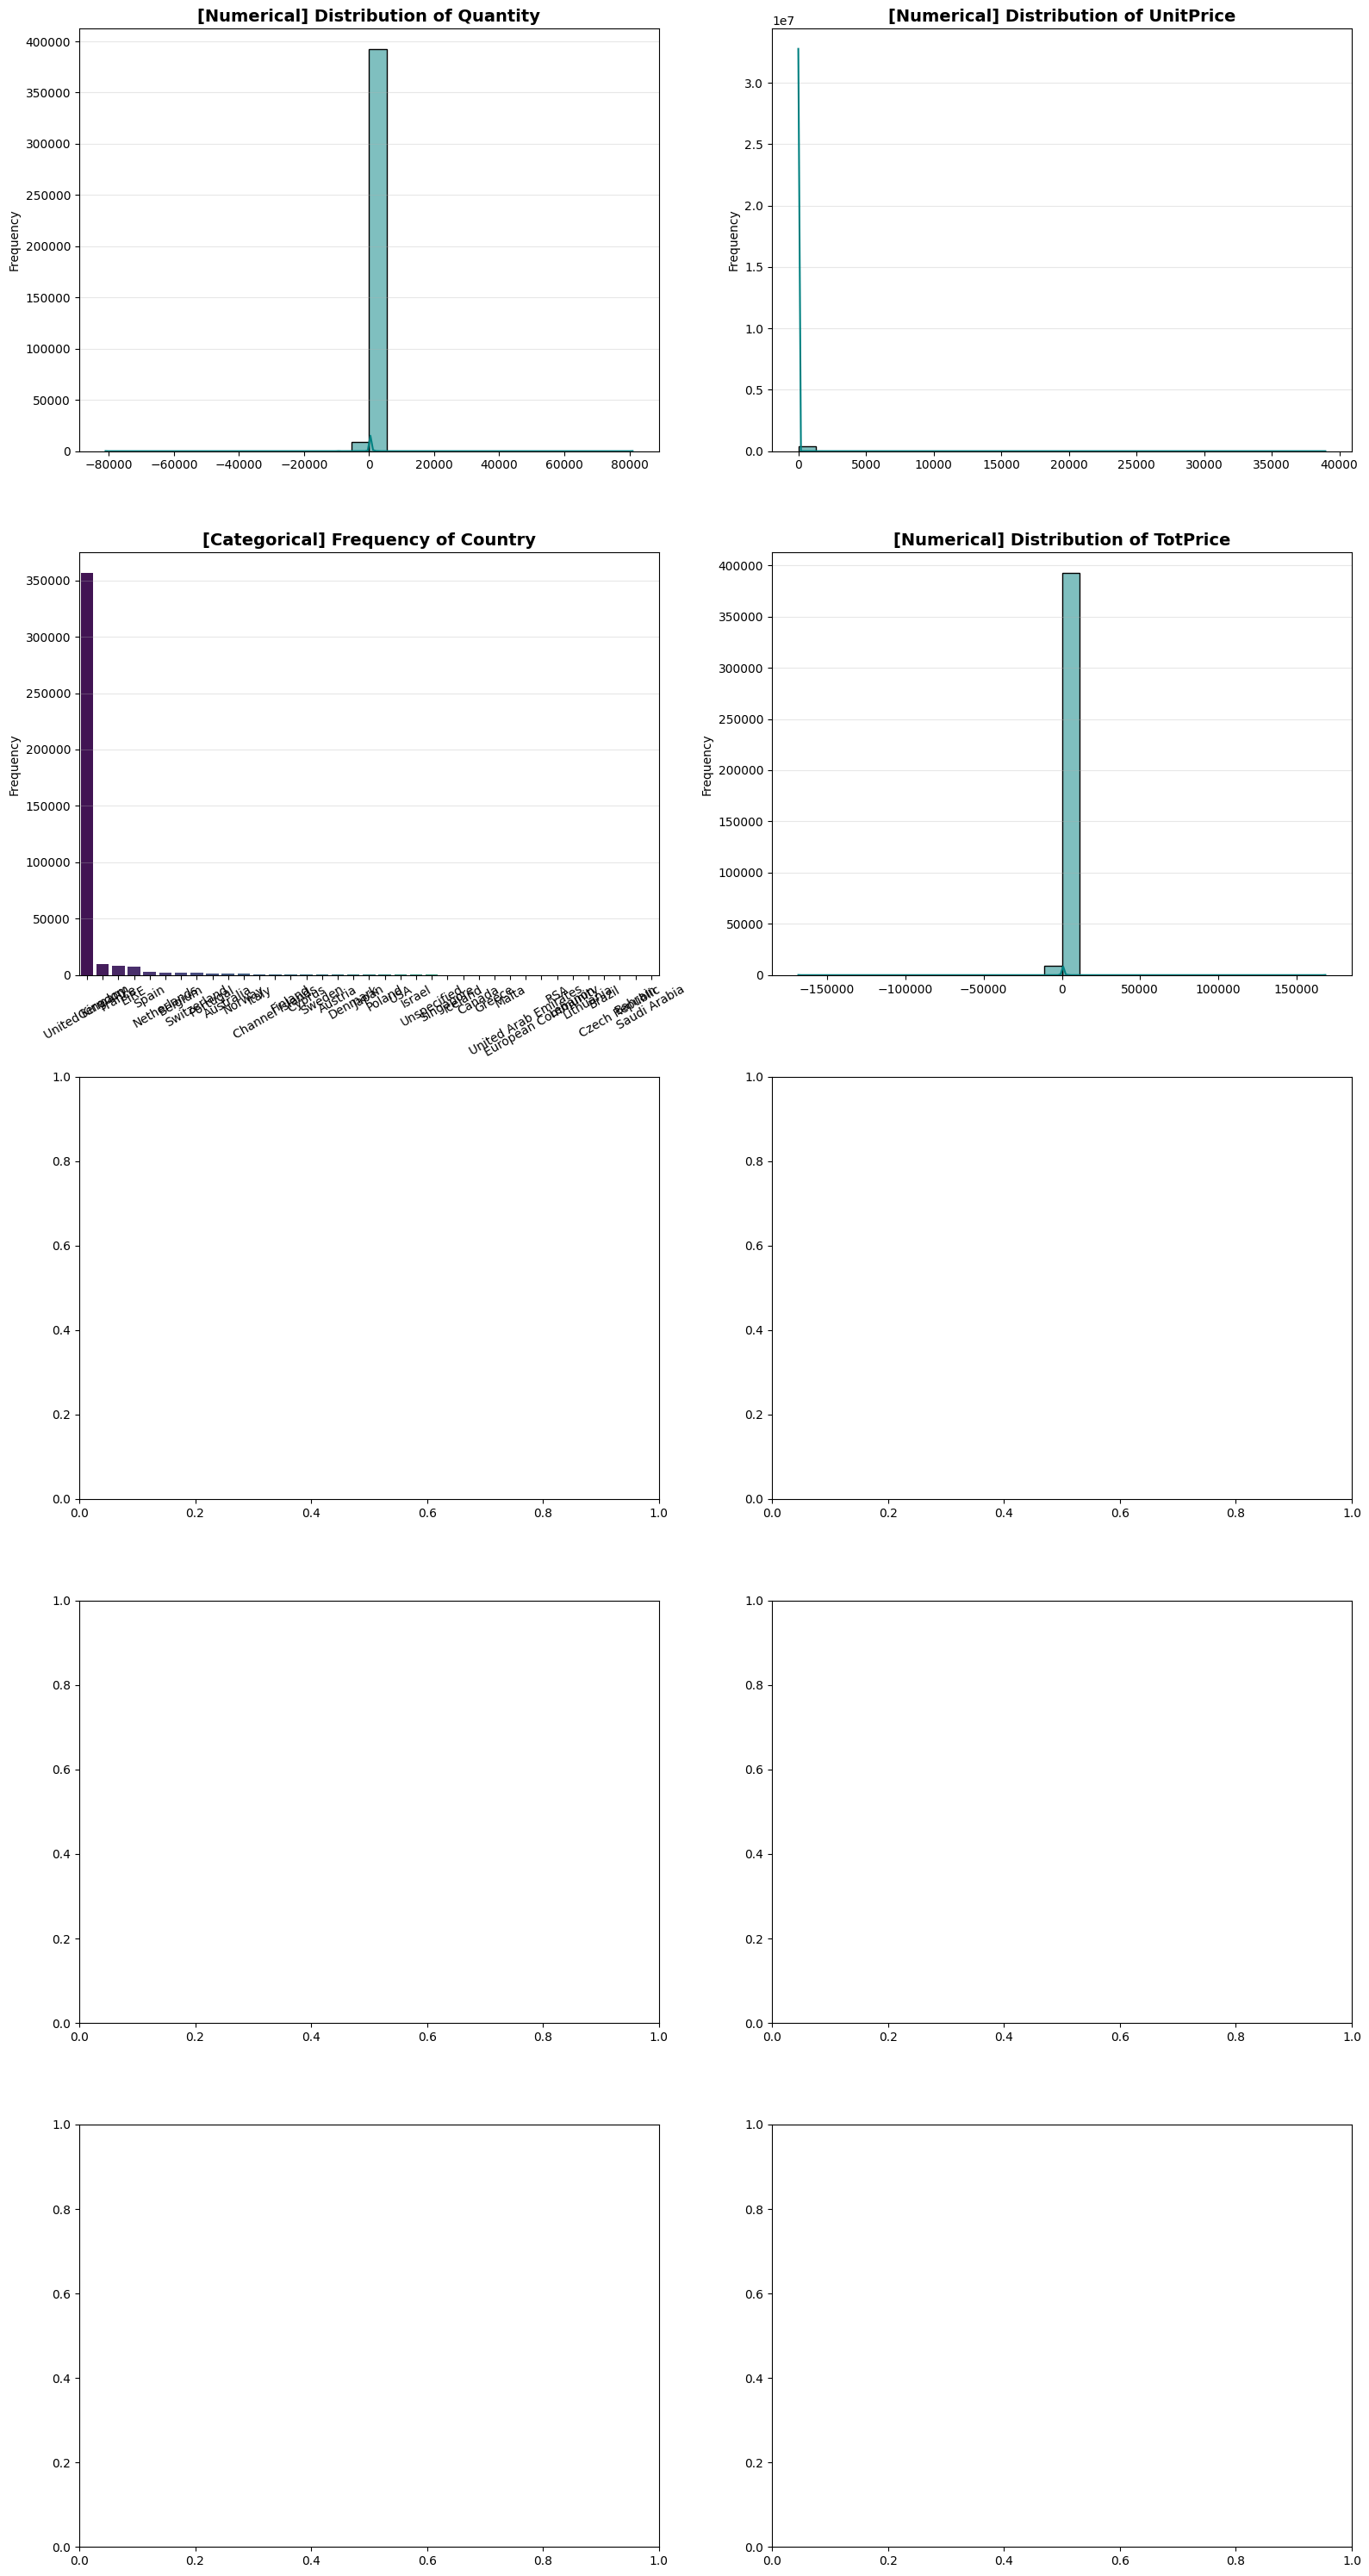

In [25]:
# 1. 분석할 10개 피처 리스트 (데이터 상황에 맞게 조정)
cols = ['Quantity', 'UnitPrice', 'Country', 'TotPrice']

# 2. 5행 2열 그리드 설정 (가로로 길게 보는 것보다 세로로 나열하는 것이 가독성이 좋음)
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(16, 30))
axes = axes.flatten()

for i, col in enumerate(cols):
    # 데이터 타입 또는 유니크 값 개수에 따라 차트 종류 결정
    # 유니크 값이 적으면 범주형으로 판단하여 countplot 적용
    if df1[col].dtype == 'object' or df1[col].nunique() < 10:
        sns.countplot(data=df1, x=col, ax=axes[i], palette='viridis', order=df1[col].value_counts().index)
        axes[i].set_title(f'[Categorical] Frequency of {col}', fontsize=14, fontweight='bold')
        # 라벨이 겹치지 않게 회전 처리
        axes[i].tick_params(axis='x', rotation=30)
    else:
        # 수치형 데이터는 도수분포의 기본인 histplot 적용
        sns.histplot(df1[col], kde=True, ax=axes[i], color='teal', bins=30)
        axes[i].set_title(f'[Numerical] Distribution of {col}', fontsize=14, fontweight='bold')

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frequency')
    axes[i].grid(axis='y', alpha=0.3)

# 3. 레이아웃 최적화
plt.tight_layout()
plt.show()

In [31]:
result = df1.loc[df1['Quantity'] < 0].groupby(['InvoiceNo', 'CustomerID']).size().reset_index(name='Count')
print(result)

     InvoiceNo  CustomerID  Count
0      C536379     14527.0      1
1      C536383     15311.0      1
2      C536391     17548.0      7
3      C536506     17897.0      1
4      C536543     17841.0      2
...        ...         ...    ...
3649   C581484     16446.0      1
3650   C581490     14397.0      2
3651   C581499     15498.0      1
3652   C581568     15311.0      1
3653   C581569     17315.0      2

[3654 rows x 3 columns]


In [35]:
result['CustomerID'].value_counts()

CustomerID
14911.0    47
17841.0    45
14606.0    35
14527.0    31
15311.0    27
           ..
13212.0     1
15793.0     1
16971.0     1
14298.0     1
13362.0     1
Name: count, Length: 1589, dtype: int64

EDA 포인트 중복 제거, 영국, 구매관련, 회원

In [ ]:
df2 = df1[['InvoiceDate', 'CustomerID', 'uniprice', 'Quantity']]